# Step 2 — Waveform Preprocessing Pipeline

**Goal:** Take `benchmark_manifest.csv` and produce `benchmark_waveforms.hdf5`.

**All waveforms loaded from local SeisBench HDF5 files — no FDSN needed for
5 of 6 datasets.** Only SCEDC (326 traces) uses the MiniSEED cache.

| Dataset | Local HDF5 | Loading method |
|---------|-----------|----------------|
| stead | 91 GB `waveforms.hdf5` | Direct h5py |
| instancecounts | 167 GB `waveforms.hdf5` | Direct h5py |
| pnw | 67 GB `waveforms.hdf5` | Direct h5py |
| txed | 75 GB `waveforms.hdf5` | Direct h5py |
| iquique | 5 GB `waveforms.hdf5` | Direct h5py |
| mlaapde | 29 GB `waveforms_YYYYMM.hdf5` | Direct h5py (monthly shards) |

| scedc | no local HDF5 | `waveform_cache/*.mseed` |
| obst2024 | no local HDF5 | Skipped |


All datasets share the same HDF5 structure:
`f["data"]["bucket{N}"][row_id]` → shape `(3, n_samples)`

MLAAPDE is at 40 Hz native — resampled to 100 Hz. All others are 100 Hz.


## 2.1  Imports & Configuration


In [34]:
import numpy as np
import pandas as pd
import h5py, re
from pathlib import Path
from tqdm.notebook import tqdm
import scipy.signal
from math import gcd
from obspy import read as obspy_read
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd


# ── Paths ──────────────────────────────────────────────────────────────────
MANIFEST_PATH   = Path("benchmark_manifest.csv")
OUTPUT_HDF5     = Path("benchmark_waveforms.hdf5")
WAVEFORM_CACHE  = Path("waveform_cache")        # MiniSEED files for SCEDC only
SEISBENCH_CACHE = Path("/data/wsd04/ak287/.seisbench/datasets")

assert MANIFEST_PATH.exists(), "benchmark_manifest.csv not found — run Step 1 first"
assert SEISBENCH_CACHE.exists(), f"SeisBench cache not found at {SEISBENCH_CACHE}"

# ── Preprocessing parameters ───────────────────────────────────────────────
TARGET_SR      = 100
WINDOW_SAMPLES = 3000       # 30 s at 100 Hz
P_JITTER_MIN   = 300
P_JITTER_MAX   = 2700
RANDOM_SEED    = 42
rng = np.random.default_rng(RANDOM_SEED)

SKIP_DATASETS = {"obst2024"}

# Datasets with local waveform HDF5 files — loaded directly
# scedc has no local HDF5 → uses waveform_cache MiniSEED
LOCAL_HDF5_DATASETS = {"stead", "instancecounts", "pnw", "txed", "iquique", "scedc", "mlaapde"}

# Native sampling rates (40 Hz for MLAAPDE, 100 Hz for all others)
NATIVE_SR = {
    "stead":          100.0,
    "instancecounts": 100.0,
    "pnw":            100.0,
    "txed":           100.0,
    "iquique":         100.0,
    "scedc":           100.0,
    "mlaapde":         40.0,

}

# ── Load manifest ──────────────────────────────────────────────────────────
manifest = pd.read_csv(MANIFEST_PATH)
has_pick = manifest["p_arrival_sample"].notna() | manifest["s_arrival_sample"].notna()
manifest = manifest[has_pick].reset_index(drop=True)
if "has_p_pick" not in manifest.columns:
    manifest["has_p_pick"] = manifest["p_arrival_sample"].notna()

print(f"Manifest: {len(manifest):,} traces")
print(manifest.groupby("dataset")["trace_name"].count().rename("n").to_string())

# ── MiniSEED path helper (SCEDC only) ──────────────────────────────────────
def mseed_path(trace_name):
    safe = trace_name.replace("/","_").replace("\\","_").replace(" ","_")
    return WAVEFORM_CACHE / f"{safe}.mseed"


Manifest: 4,476 traces
dataset
instancecounts     845
iquique            320
mlaapde           1350
obst2024           400
pnw                378
scedc              326
stead              672
txed               185


## 2.2  Waveform Loader

All SeisBench datasets share the same HDF5 structure:
```
waveforms.hdf5  (or waveforms_YYYYMM.hdf5 for MLAAPDE)
└── data/
    ├── bucket0/   shape (n_traces, 3, n_samples)
    ├── bucket1/   ...
    └── ...
```

`trace_name` encodes location: `bucket{N}${row},:3,:{samples}`
→ `f["data"]["bucket{N}"][row]`

One function handles all local datasets. MLAAPDE uses monthly shards
identified by the `source_month` column in the manifest.


In [35]:
def parse_trace_name(trace_name):
    """Parse 'bucket{N}${row},:3,:{samples}' → (bucket_id, row_id)."""
    m = re.match(r"bucket(\d+)\$(\d+)", trace_name)
    if not m:
        raise ValueError(f"Unrecognised trace_name: {trace_name!r}")
    return int(m.group(1)), int(m.group(2))


def load_waveform_local(ds_name, trace_name, source_month=None):
    """
    Load a waveform directly from the local SeisBench HDF5 file.
    Works for all datasets with the bucket structure:
        f['data']['bucket{N}'][row_id]  →  (3, n_samples)

    Parameters
    ----------
    ds_name      : 'stead', 'instancecounts', 'pnw', 'txed', 'mlaapde'
    trace_name   : e.g. 'bucket0$42891,:3,:6000'
    source_month : MLAAPDE only — '201408' (from manifest, normalised to int str)
    """
    bucket_id, row_id = parse_trace_name(trace_name)

    if ds_name == "mlaapde":
        month_str = str(int(float(source_month)))
        hdf5_path = SEISBENCH_CACHE / "mlaapde" / f"waveforms_{month_str}.hdf5"
    else:
        hdf5_path = SEISBENCH_CACHE / ds_name / "waveforms.hdf5"

    with h5py.File(hdf5_path, "r") as f:
        waveform = f["data"][f"bucket{bucket_id}"][row_id]

    return np.array(waveform, dtype=np.float32)


# ── Scan SCEDC MiniSEED cache ──────────────────────────────────────────────
print("Scanning waveform_cache for SCEDC MiniSEED files...", end=" ")
cached_stems   = {f.stem for f in WAVEFORM_CACHE.glob("*.mseed")}
scedc_manifest = manifest[manifest["dataset"] == "scedc"]
scedc_cached   = scedc_manifest[scedc_manifest["trace_name"].apply(
                     lambda t: mseed_path(t).stem in cached_stems)]
scedc_missing  = scedc_manifest[~scedc_manifest["trace_name"].apply(
                     lambda t: mseed_path(t).stem in cached_stems)]
print(f"{len(cached_stems):,} files found")

print(f"\nExpected traces:")
for ds in manifest["dataset"].unique():
    n = (manifest["dataset"] == ds).sum()
    if ds in LOCAL_HDF5_DATASETS:
        print(f"  {ds:20s}: {n:>5,}  (local HDF5)")
    elif ds == "scedc":
        print(f"  {ds:20s}: {len(scedc_cached):>5,}  (MiniSEED cache, {len(scedc_missing):,} missing)")
    elif ds in SKIP_DATASETS:
        print(f"  {ds:20s}: {n:>5,}  (skipped)")
print(f"  {'─'*40}")
n_expected = (manifest["dataset"].isin(LOCAL_HDF5_DATASETS)).sum() + len(scedc_cached)
print(f"  {'Total expected':20s}: {n_expected:>5,}")


Scanning waveform_cache for SCEDC MiniSEED files... 1,094 files found

Expected traces:
  instancecounts      :   845  (local HDF5)
  stead               :   672  (local HDF5)
  pnw                 :   378  (local HDF5)
  scedc               :   326  (local HDF5)
  txed                :   185  (local HDF5)
  mlaapde             : 1,350  (local HDF5)
  iquique             :   320  (local HDF5)
  obst2024            :   400  (skipped)
  ────────────────────────────────────────
  Total expected      : 4,076


## 2.3  Preprocessing Functions

| Function | Purpose |
|----------|---------|
| `resample_waveform` | Polyphase resampling to 100 Hz — handles MLAAPDE at 40 Hz |
| `extract_window` | 30 s window with random jitter — anchors on P or S |
| `normalize_waveform` | Zero-mean, unit-std per component |
| `compute_snr_db` | Pre-P noise vs post-P signal window |
| `check_quality` | Detects NaN, flat-line channels, too many zeros |


In [36]:
from math import gcd

def resample_waveform(data, orig_sr, target_sr=TARGET_SR):
    """Polyphase resample (n_comp, n_samples) from orig_sr → target_sr."""
    if abs(orig_sr - target_sr) < 0.5:
        return data.astype(np.float32)
    up   = int(round(target_sr))
    down = int(round(orig_sr))
    g    = gcd(up, down);  up //= g;  down //= g
    return scipy.signal.resample_poly(data, up, down, axis=-1,
                                      padtype="line").astype(np.float32)

def rescale_sample(sample, orig_sr, target_sr=TARGET_SR):
    return int(round(sample * target_sr / orig_sr))

def extract_window(waveform, anchor_samp, other_samp=None,
                   wlen=WINDOW_SAMPLES, pmin=P_JITTER_MIN, pmax=P_JITTER_MAX, rng=rng):
    """
    Extract a waveform window centred on `anchor_samp` (normally P, but S for S-only traces).
    `other_samp` is the position of the secondary phase (S if anchoring on P, or vice versa).
    Returns (window, anchor_in_window, other_in_window) where other_in_window = -1 if absent.
    """
    n = waveform.shape[-1]
    offset    = int(rng.integers(pmin, pmax))   # anchor placed randomly in [pmin, pmax]
    win_start = anchor_samp - offset
    win_end   = win_start + wlen
    if win_start < 0 or win_end > n:
        pad_l = max(0, -win_start);  pad_r = max(0, win_end - n)
        waveform  = np.pad(waveform, ((0,0),(pad_l,pad_r)))
        win_start += pad_l;  win_end += pad_l
    window = waveform[:, win_start:win_end].astype(np.float32)
    other_in_win = -1
    if other_samp is not None and np.isfinite(other_samp):
        other_in_win = int(round(other_samp)) - win_start
        if not (0 <= other_in_win < wlen):
            other_in_win = -1
    return window, offset, other_in_win

def normalize_waveform(w, eps=1e-10):
    out = np.zeros_like(w, dtype=np.float32)
    for i in range(w.shape[0]):
        c = w[i].astype(np.float64)
        std = np.nanstd(c)
        if std > eps:
            out[i] = ((c - np.nanmean(c)) / std).astype(np.float32)
    return out

def compute_snr_db(w, p_pos, noise_len=200, signal_len=200):
    n_comp, n_samp = w.shape
    ns = max(0, p_pos - noise_len);  ne = p_pos
    ss = p_pos;  se = min(n_samp, p_pos + signal_len)
    if ne <= ns or se <= ss:
        return np.nan
    snrs = []
    for c in range(n_comp):
        nr = np.sqrt(np.mean(w[c,ns:ne]**2))
        sr = np.sqrt(np.mean(w[c,ss:se]**2))
        if nr > 1e-12:
            snrs.append(20*np.log10(sr/nr + 1e-12))
    return float(np.mean(snrs)) if snrs else np.nan

def check_quality(w, min_nonzero=0.8, p_in_window=None):
    """
    Quality check on a 3-component waveform window.

    The zero-fraction check is applied only around the P arrival
    (3 s before to 10 s after) when p_in_window is provided.
    This prevents rejecting INSTANCE traces where long pre/post-event
    periods are exactly zero but the earthquake signal is present.
    The flat-line check still runs on the full window to catch broken sensors.
    """
    if np.any(np.isnan(w)):
        return False, "contains_nan"

    # Zero fraction — check P-signal region if available, else full window
    if p_in_window is not None and p_in_window >= 0:
        pre_p   = max(0, p_in_window - 300)              # 3 s before P
        post_p  = min(w.shape[-1], p_in_window + 1000)   # 10 s after P
        w_check = w[:, pre_p:post_p]
    else:
        w_check = w

    if np.count_nonzero(w_check) / w_check.size < min_nonzero:
        return False, "too_many_zeros"

    # Flat-line check on full window — catches broken/silent sensors
    for i in range(w.shape[0]):
        if np.std(w[i]) < 1e-12:
            return False, f"flat_component_{i}"

    return True, None

print("Preprocessing functions ready.")


Preprocessing functions ready.


## 2.4  Processing Loop

One unified loop for all datasets. Two paths based on data source:

- **Local HDF5** (stead, instancecounts, pnw, txed, mlaapde) — `load_waveform_local()`
- **MiniSEED cache** (scedc only) — `obspy_read()`

HDF5 opened in append mode — safe to re-run after downloading more files.
MLAAPDE resampled from 40 Hz → 100 Hz; all others assumed 100 Hz.


In [37]:
skip_log    = []
success_log = []

hdf5_mode = "a" if OUTPUT_HDF5.exists() else "w"
print(f"Opening {OUTPUT_HDF5} in '{hdf5_mode}' mode")

with h5py.File(OUTPUT_HDF5, hdf5_mode) as hf:
    wf_grp  = hf.require_group("waveforms")
    p_grp   = hf.require_group("p_sample")
    s_grp   = hf.require_group("s_sample")
    snr_grp = hf.require_group("snr_db")

    already = len(wf_grp)
    print(f"Traces already in HDF5: {already:,}\n")

    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Processing"):
        tname   = row["trace_name"]
        ds_name = row["dataset"]

        # ── Skip excluded datasets ─────────────────────────────────────────
        if ds_name in SKIP_DATASETS:
            skip_log.append({"trace_name": tname, "dataset": ds_name,
                              "reason": "dataset_skipped_no_local_waveforms"})
            continue

        if tname in wf_grp:
            continue   # already written — safe to re-run

        # ── Pick availability ──────────────────────────────────────────────
        has_p = bool(row.get("has_p_pick", pd.notna(row["p_arrival_sample"])))
        has_s = bool(row["has_s_pick"])
        if not has_p and not has_s:
            skip_log.append({"trace_name": tname, "dataset": ds_name,
                              "reason": "no_picks"})
            continue

        # ══════════════════════════════════════════════════════════════════
        # PATH A — Local HDF5 (stead, instancecounts, pnw, txed, mlaapde)
        # ══════════════════════════════════════════════════════════════════
        if ds_name in LOCAL_HDF5_DATASETS:
            source_month = row.get("source_month", None)
            try:
                waveform = load_waveform_local(ds_name, tname, source_month)
                if waveform.ndim == 1:
                    waveform = waveform[np.newaxis, :]
            except Exception as e:
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": f"load_error:{str(e)[:60]}"})
                continue
            native_sr = NATIVE_SR.get(ds_name, 100.0)

        # ══════════════════════════════════════════════════════════════════
        # PATH B — MiniSEED cache (scedc only)
        # ══════════════════════════════════════════════════════════════════
        elif ds_name == "scedc":
            if not mseed_path(tname).exists():
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": "mseed_not_in_cache"})
                continue
            try:
                st = obspy_read(str(mseed_path(tname)), format="MSEED")
                st.merge(fill_value=0)
                st.sort(["channel"])
                traces_data = [tr.data.astype(np.float32) for tr in st]
                if not traces_data:
                    raise ValueError("empty stream")
                max_len  = max(len(d) for d in traces_data)
                waveform = np.zeros((3, max_len), dtype=np.float32)
                for i, d in enumerate(traces_data[:3]):
                    waveform[i, :len(d)] = d
                native_sr = float(st[0].stats.sampling_rate)
            except Exception as e:
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": f"mseed_error:{str(e)[:50]}"})
                continue

        else:
            skip_log.append({"trace_name": tname, "dataset": ds_name,
                              "reason": "no_loader_defined"})
            continue

        # ══════════════════════════════════════════════════════════════════
        # COMMON: resample → rescale picks → window → quality → write
        # ══════════════════════════════════════════════════════════════════
        if abs(native_sr - TARGET_SR) > 0.5:
            try:
                waveform = resample_waveform(waveform, native_sr, TARGET_SR)
            except Exception as e:
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": f"resample_error:{str(e)[:40]}"})
                continue

        p_raw  = float(row["p_arrival_sample"]) if has_p else np.nan
        s_raw  = float(row["s_arrival_sample"]) if has_s else np.nan
        p_samp = rescale_sample(p_raw, native_sr, TARGET_SR) if has_p else None
        s_samp = rescale_sample(s_raw, native_sr, TARGET_SR) if has_s else None
        n_samp = waveform.shape[-1]

        if has_p:
            if p_samp < 0 or p_samp >= n_samp:
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": f"p_outside_trace({p_samp},{n_samp})"})
                continue
            # Clamp jitter to what the trace actually allows
            # (recovers traces where P is close to the start)
            p_min = min(P_JITTER_MIN, p_samp)
            p_max = min(P_JITTER_MAX, n_samp - (WINDOW_SAMPLES - p_samp))
            if p_min >= p_max:
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": f"p_window_impossible({p_samp},{n_samp})"})
                continue
            window, p_in_win, s_in_win = extract_window(
                waveform, p_samp, s_samp, pmin=p_min, pmax=p_max)
        else:
            # S-only (one MLAAPDE trace)
            if not (P_JITTER_MIN <= s_samp <= n_samp-(WINDOW_SAMPLES-P_JITTER_MAX)):
                skip_log.append({"trace_name": tname, "dataset": ds_name,
                                  "reason": f"s_near_edge({s_samp},{n_samp})"})
                continue
            window, s_in_win, _ = extract_window(waveform, s_samp, None)
            p_in_win = -1

        ok, reason = check_quality(window, p_in_window=p_in_win)
        if not ok:
            skip_log.append({"trace_name": tname, "dataset": ds_name,
                              "reason": f"quality:{reason}"})
            continue

        snr_ref = p_in_win if p_in_win >= 0 else s_in_win
        snr     = compute_snr_db(window, snr_ref)
        window  = normalize_waveform(window)

        wf_grp.create_dataset(tname, data=window, dtype="float32")
        p_grp.create_dataset(tname,  data=np.int16(p_in_win))
        s_grp.create_dataset(tname,  data=np.int16(s_in_win))
        snr_grp.create_dataset(tname, data=np.float32(snr))
        success_log.append({"trace_name": tname, "dataset": ds_name,
                             "p_in_window": p_in_win, "s_in_window": s_in_win,
                             "snr_db": snr, "actual_sr": TARGET_SR})

print(f"\nDone.")
print(f"  Written this run : {len(success_log):,}")
print(f"  Total in HDF5    : {already + len(success_log):,}")
print(f"  Skipped          : {len(skip_log):,}")
if skip_log:
    from collections import Counter
    for reason, n in Counter(r["reason"].split(":")[0]
                             for r in skip_log).most_common():
        print(f"    {n:>5,} — {reason}")


Opening benchmark_waveforms.hdf5 in 'a' mode
Traces already in HDF5: 3,448



Processing:   0%|          | 0/4476 [00:00<?, ?it/s]


Done.
  Written this run : 317
  Total in HDF5    : 3,765
  Skipped          : 651
      400 — dataset_skipped_no_local_waveforms
      241 — quality
        1 — p_outside_trace(-685,1848)
        1 — p_outside_trace(-918,2662)
        1 — p_outside_trace(-552,1540)
        1 — p_outside_trace(-567,6624)
        1 — p_window_impossible(636,2218)
        1 — p_window_impossible(165,1848)
        1 — p_outside_trace(-158,6624)
        1 — p_outside_trace(-191,1848)
        1 — p_outside_trace(-234,4594)
        1 — p_outside_trace(-11620,13323)


In [38]:
with h5py.File(OUTPUT_HDF5, "r") as hf:
    n_in_hdf5 = len(hf["waveforms"])
print(f"Traces in HDF5       : {n_in_hdf5:,}")
print(f"Traces in success_log: {len(success_log):,}")
print(f"From previous run    : {n_in_hdf5 - len(success_log):,}")

Traces in HDF5       : 3,765
Traces in success_log: 317
From previous run    : 3,448


## 2.7  Save Processing Index

In [39]:
# ── Save processing index ──────────────────────────────────────────────────
# Query HDF5 for ALL written traces — not just ones written this run.
# This correctly handles append-mode re-runs where some traces were
# already written in a previous session.

with h5py.File(OUTPUT_HDF5, "r") as hf:
    written_in_hdf5 = set(hf["waveforms"].keys())
    # Collect p/s positions and SNR for all written traces
    hdf5_meta = {}
    for tname in written_in_hdf5:
        hdf5_meta[tname] = {
            "p_in_window": int(hf["p_sample"][tname][()]),
            "s_in_window": int(hf["s_sample"][tname][()]),
            "snr_db":      float(hf["snr_db"][tname][()]),
            "actual_sr":   TARGET_SR,
            "status":      "ok",
        }

print(f"Traces in HDF5: {len(written_in_hdf5):,}")

# Build index from manifest — status comes from HDF5, not success_log
skip_df = pd.DataFrame(skip_log) if skip_log else pd.DataFrame(
              columns=["trace_name","dataset","reason"])
skip_df["status"] = "skipped"

hdf5_df = pd.DataFrame.from_dict(hdf5_meta, orient="index").reset_index()
hdf5_df = hdf5_df.rename(columns={"index": "trace_name"})

index_df = manifest.merge(hdf5_df, on="trace_name", how="left")
index_df["status"] = index_df["status"].fillna("skipped")

skip_reason = (skip_df.set_index("trace_name")["reason"]
               if len(skip_df) else pd.Series(dtype=str))
index_df["skip_reason"] = index_df["trace_name"].map(skip_reason)

index_df.to_csv("benchmark_waveforms_index.csv", index=False)
print(f"Saved benchmark_waveforms_index.csv  ({len(index_df):,} rows)")
print(f"  ok      : {(index_df['status']=='ok').sum():,}")
print(f"  skipped : {(index_df['status']=='skipped').sum():,}")
if len(skip_df):
    from collections import Counter
    print("\nSkip reasons:")
    for reason, n in Counter(skip_df["reason"].str.split(":").str[0]).most_common():
        print(f"  {n:>5,} — {reason}")

Traces in HDF5: 3,765
Saved benchmark_waveforms_index.csv  (4,476 rows)
  ok      : 3,825
  skipped : 651

Skip reasons:
    400 — dataset_skipped_no_local_waveforms
    241 — quality
      1 — p_outside_trace(-685,1848)
      1 — p_outside_trace(-918,2662)
      1 — p_outside_trace(-552,1540)
      1 — p_outside_trace(-567,6624)
      1 — p_window_impossible(636,2218)
      1 — p_window_impossible(165,1848)
      1 — p_outside_trace(-158,6624)
      1 — p_outside_trace(-191,1848)
      1 — p_outside_trace(-234,4594)
      1 — p_outside_trace(-11620,13323)


## 2.8  Quality Summary

Written: 3,825 / 4,476  (85.5%)
dataset
instancecounts     687
iquique            320
mlaapde           1349
pnw                295
scedc              317
stead              672
txed               185


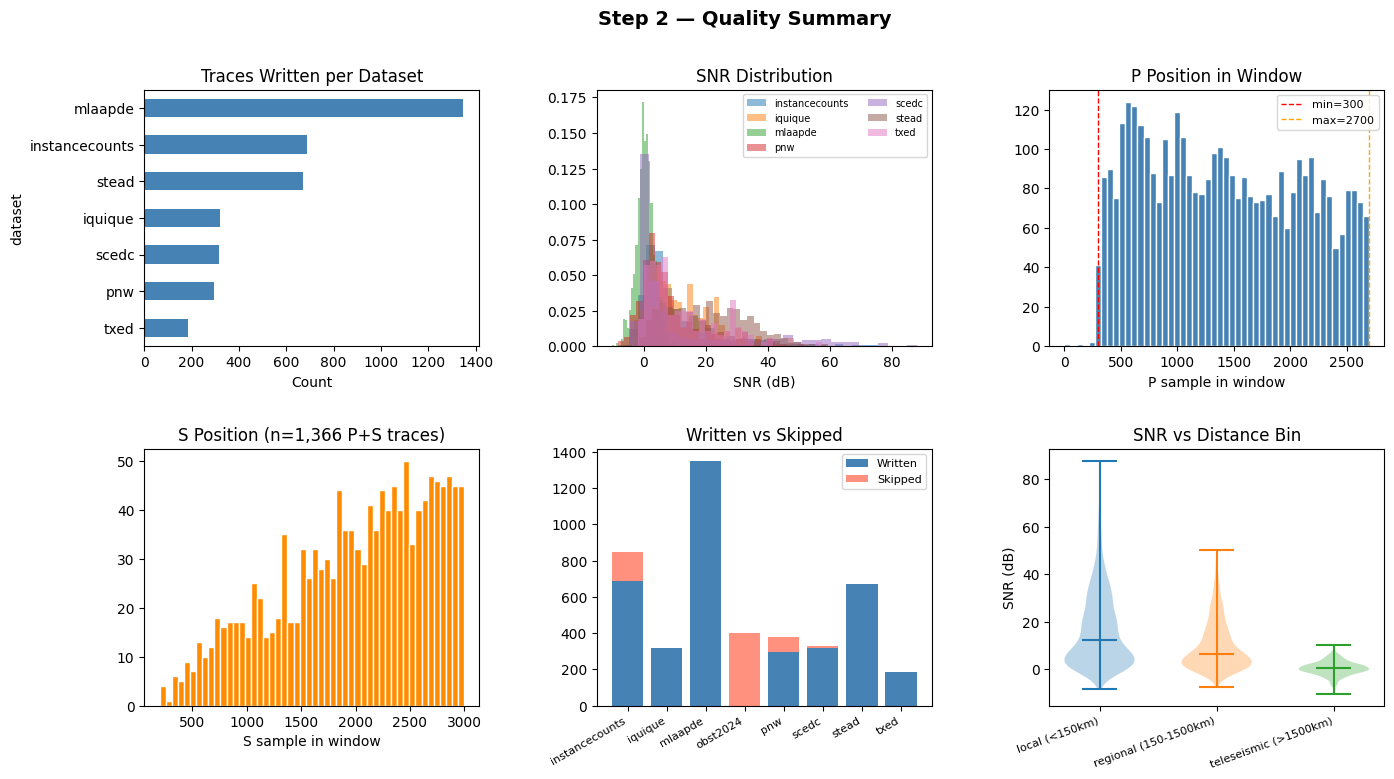

Saved → step2_quality_summary.png


In [40]:
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec

idx = pd.read_csv("benchmark_waveforms_index.csv")
ok  = idx[idx["status"] == "ok"]
print(f"Written: {len(ok):,} / {len(idx):,}  ({100*len(ok)/len(idx):.1f}%)")
print(ok.groupby("dataset")["trace_name"].count().rename("n_written").to_string())

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("Step 2 — Quality Summary", fontsize=14, fontweight="bold")
COLORS = plt.cm.tab10.colors

# Written per dataset
ax1 = fig.add_subplot(gs[0,0])
ok.groupby("dataset")["trace_name"].count().sort_values().plot(
    kind="barh", ax=ax1, color="steelblue")
ax1.set_title("Traces Written per Dataset"); ax1.set_xlabel("Count")

# SNR distribution
ax2 = fig.add_subplot(gs[0,1])
for i,(ds,grp) in enumerate(ok.groupby("dataset")):
    ax2.hist(grp["snr_db"].dropna(), bins=30, alpha=0.5, density=True,
             label=ds, color=COLORS[i%10])
ax2.set_xlabel("SNR (dB)"); ax2.set_title("SNR Distribution"); ax2.legend(fontsize=7,ncol=2)

# P position in window
ax3 = fig.add_subplot(gs[0,2])
ax3.hist(ok["p_in_window"].dropna(), bins=50, color="steelblue", edgecolor="white")
ax3.axvline(P_JITTER_MIN,color="red",linestyle="--",lw=1,label=f"min={P_JITTER_MIN}")
ax3.axvline(P_JITTER_MAX,color="orange",linestyle="--",lw=1,label=f"max={P_JITTER_MAX}")
ax3.set_xlabel("P sample in window"); ax3.set_title("P Position in Window"); ax3.legend(fontsize=8)

# S position
ax4 = fig.add_subplot(gs[1,0])
has_s = ok[ok["s_in_window"]>=0]
ax4.hist(has_s["s_in_window"],bins=50,color="darkorange",edgecolor="white")
ax4.set_xlabel("S sample in window"); ax4.set_title(f"S Position (n={len(has_s):,} P+S traces)")

# Written vs skipped
ax5 = fig.add_subplot(gs[1,1])
ds_tot = idx.groupby("dataset")["trace_name"].count()
ds_ok  = ok.groupby("dataset")["trace_name"].count().reindex(ds_tot.index,fill_value=0)
x = np.arange(len(ds_tot))
ax5.bar(x, ds_ok, label="Written", color="steelblue")
ax5.bar(x, ds_tot-ds_ok, bottom=ds_ok, label="Skipped", color="tomato",alpha=0.7)
ax5.set_xticks(x); ax5.set_xticklabels(ds_tot.index,rotation=30,ha="right",fontsize=8)
ax5.set_title("Written vs Skipped"); ax5.legend(fontsize=8)

# SNR vs distance bin
ax6 = fig.add_subplot(gs[1,2])
bins = ok["dist_bin"].unique()
for i,(b,grp) in enumerate(ok.groupby("dist_bin")):
    ax6.violinplot([grp["snr_db"].dropna().values], positions=[i],
                   showmedians=True, widths=0.6)
ax6.set_xticks(range(len(bins)))
ax6.set_xticklabels(bins,rotation=20,ha="right",fontsize=8)
ax6.set_ylabel("SNR (dB)"); ax6.set_title("SNR vs Distance Bin")

plt.savefig("step2_quality_summary.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved → step2_quality_summary.png")


Written: 3,955 / 4,476  (88.4%)
dataset
instancecounts     687
iquique            320
mlaapde           1479
pnw                295
scedc              317
stead              672
txed               185


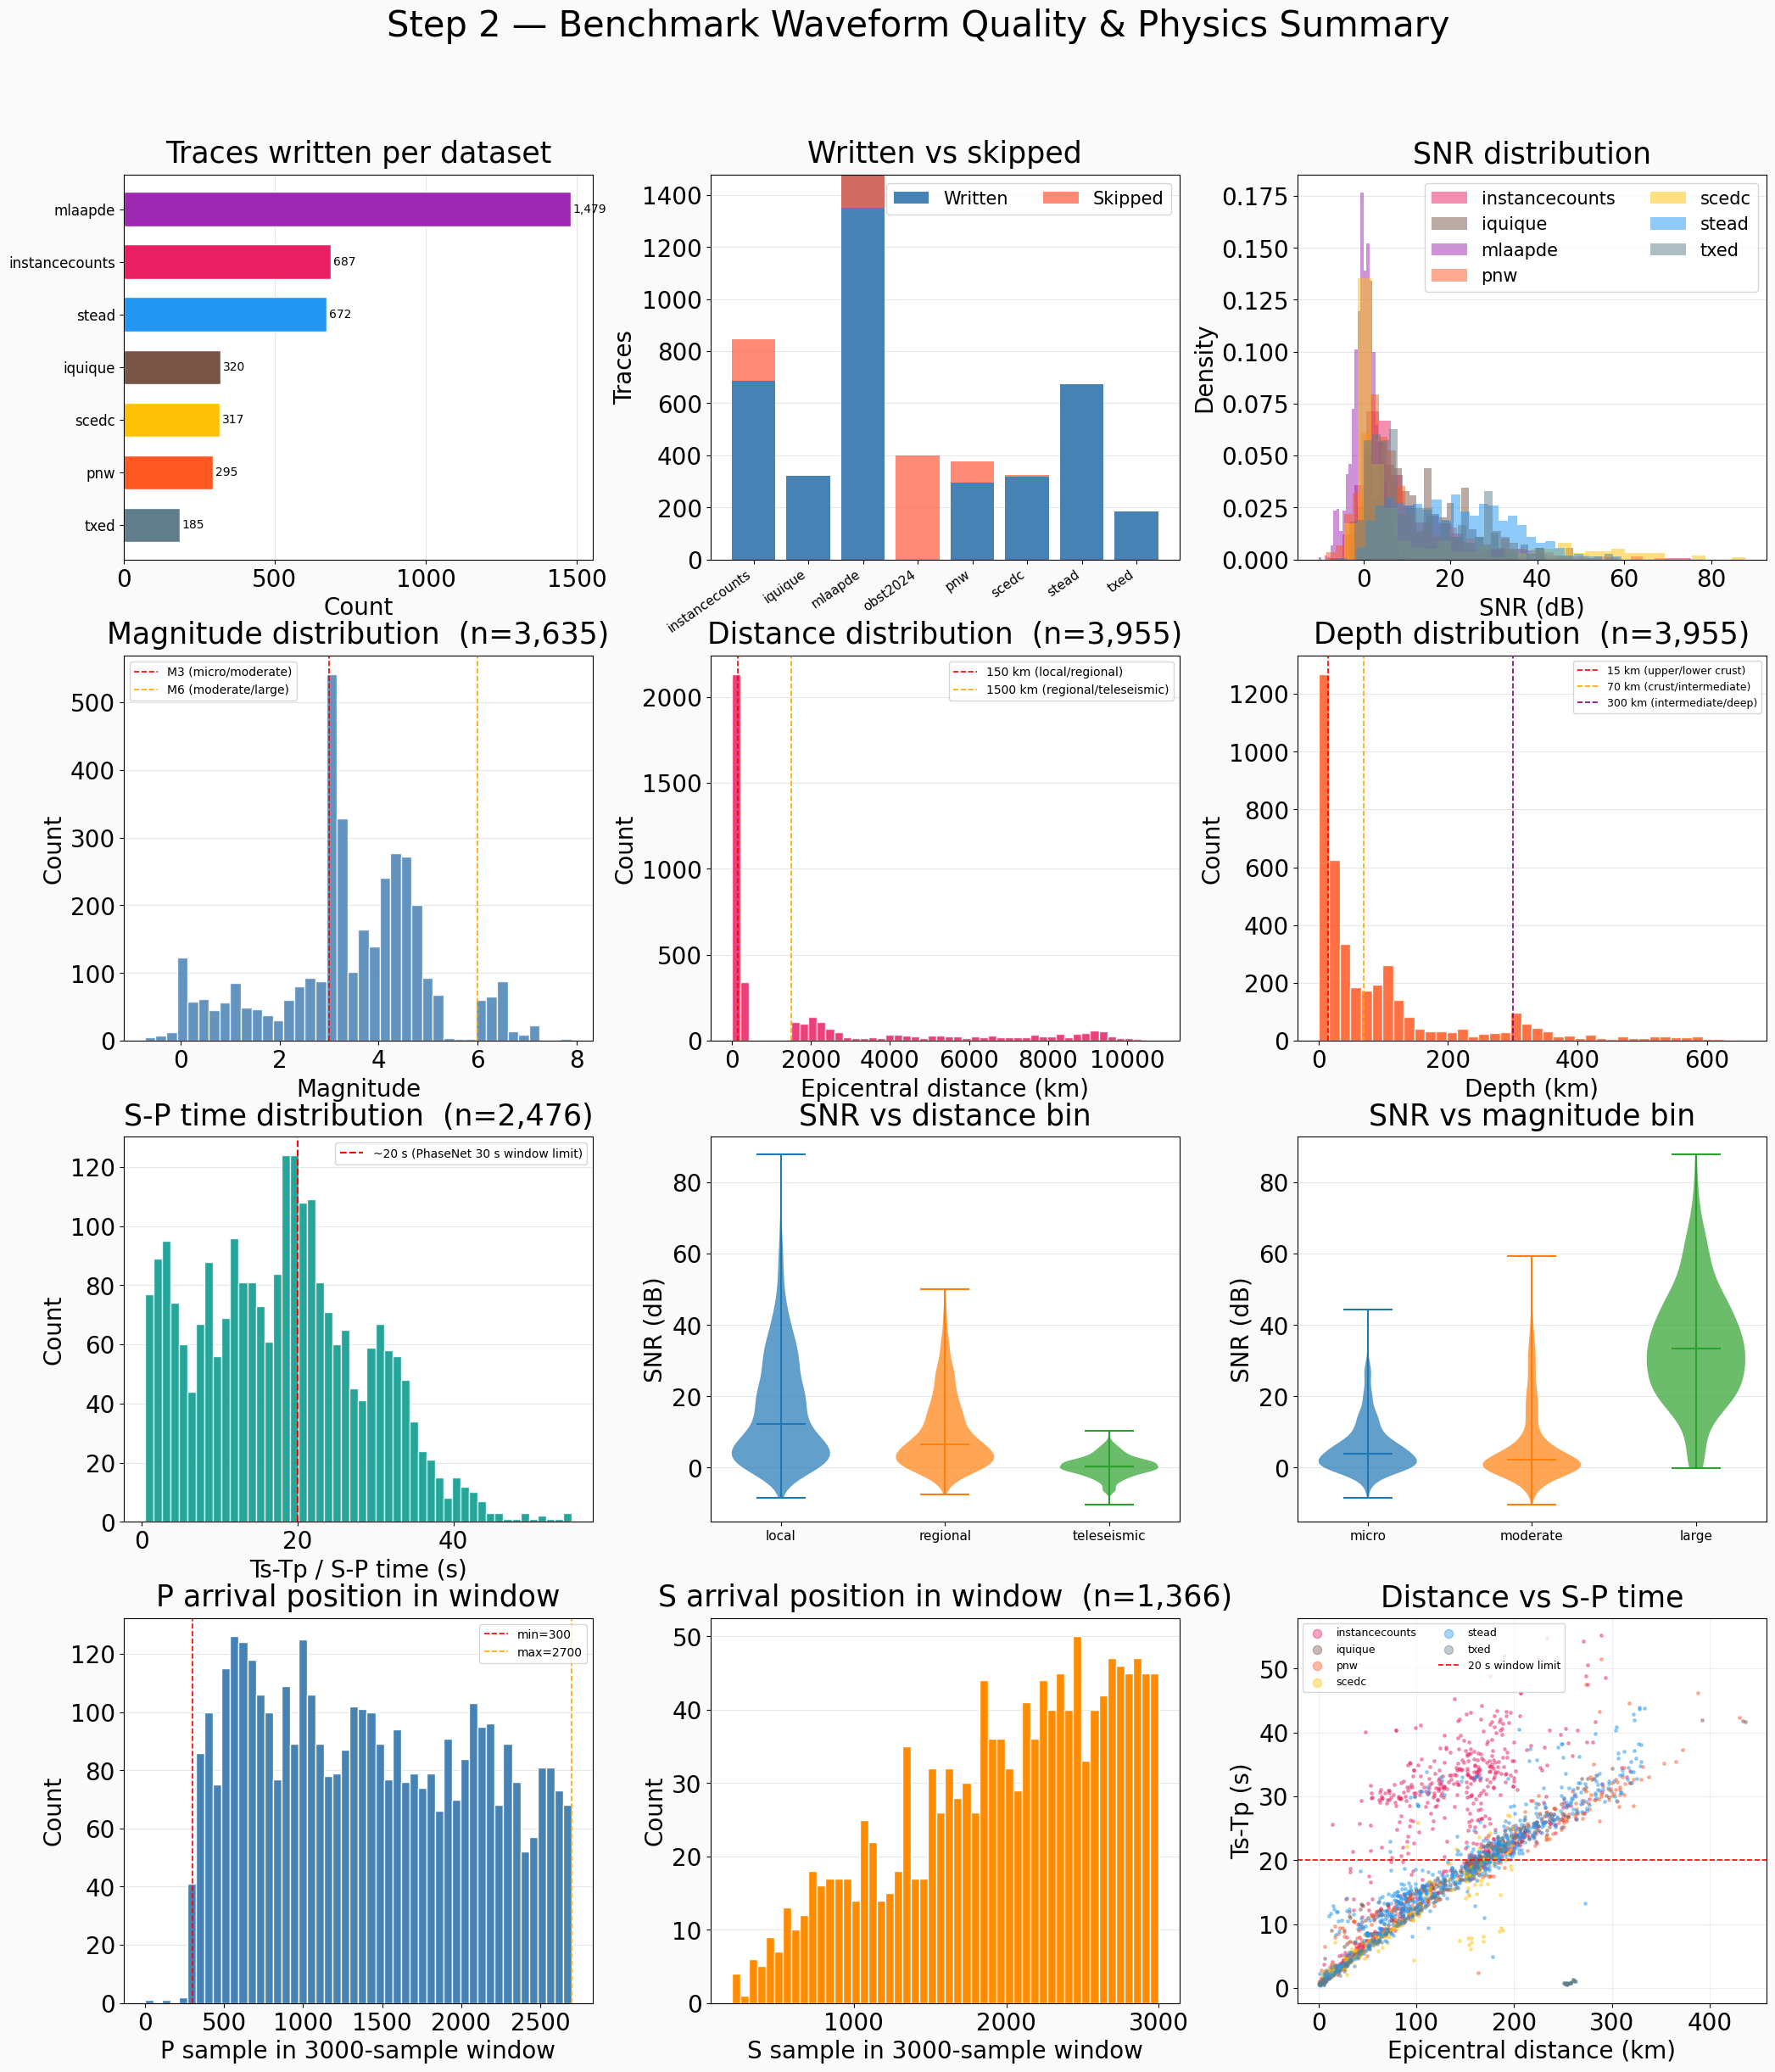

Saved → step2_quality_summary.png


In [53]:
# ── Load and merge ─────────────────────────────────────────────────────────
idx      = pd.read_csv("benchmark_waveforms_index.csv")
ok       = idx[idx["status"] == "ok"].copy()
manifest = pd.read_csv("benchmark_manifest.csv")

# Merge physics columns from manifest into ok df
phys_cols = ["trace_name","magnitude","depth_km","distance_km","ts_tp_s",
             "dist_bin","depth_bin","mag_bin"]
ok = ok.merge(manifest[phys_cols], on="trace_name", how="left",
              suffixes=("","_m"))
# prefer manifest values if index already has them
for c in ["dist_bin","depth_bin","mag_bin"]:
    if c+"_m" in ok.columns:
        ok[c] = ok[c].fillna(ok[c+"_m"])
        ok.drop(columns=[c+"_m"], inplace=True)

print(f"Written: {len(ok):,} / {len(idx):,}  ({100*len(ok)/len(idx):.1f}%)")
print(ok.groupby("dataset")["trace_name"].count().rename("n_written").to_string())

# ── Palette ────────────────────────────────────────────────────────────────
DS_COLORS = {
    "stead":          "#2196F3",
    "scedc":          "#FFC107",
    "instancecounts": "#E91E63",
    "pnw":            "#FF5722",
    "txed":           "#607D8B",
    "mlaapde":        "#9C27B0",
    "iquique":        "#795548",
    "obst2024":       "#009688",
}
COLORS = [DS_COLORS.get(ds, "#888") for ds in ok["dataset"].unique()]

# ── Figure: 4 rows × 3 cols ────────────────────────────────────────────────
fig = plt.figure(figsize=(25, 28))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.25, wspace = 0.25)

TITLE_KW = dict(fontsize= 25, pad=10)
TICK_KW  = dict(labelsize=20)
LAB_KW   = dict(fontsize=20)
LEG_KW   = dict(fontsize=15, ncol=2)

fig.suptitle("Step 2 — Benchmark Waveform Quality & Physics Summary",
             fontsize=30, y=0.95)

# ── 1. Traces written per dataset ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = ok.groupby("dataset")["trace_name"].count().sort_values()
bars = ax1.barh(counts.index, counts.values,
                color=[DS_COLORS.get(d,"#888") for d in counts.index],
                edgecolor="white", height=0.65)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
             f"{val:,}", va="center", fontsize=10)
ax1.tick_params(axis="y", labelsize=12)   # bigger dataset names
ax1.tick_params(axis="x", **TICK_KW)
ax1.set_title("Traces written per dataset", **TITLE_KW)
ax1.set_xlabel("Count", **LAB_KW)
ax1.set_facecolor("white"); ax1.xaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)

# ── 2. Written vs skipped per dataset ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ds_tot = idx.groupby("dataset")["trace_name"].count()
ds_ok  = ok.groupby("dataset")["trace_name"].count().reindex(ds_tot.index, fill_value=0)
x = np.arange(len(ds_tot))
ax2.bar(x, ds_ok, color="steelblue", label="Written")
ax2.bar(x, ds_tot-ds_ok, bottom=ds_ok, color="tomato", alpha=0.75, label="Skipped")
ax2.set_xticks(x)
ax2.set_xticklabels(ds_tot.index, rotation=35, ha="right", fontsize=11)
ax2.tick_params(axis="y", **TICK_KW)
ax2.set_title("Written vs skipped", **TITLE_KW)
ax2.set_ylabel("Traces", **LAB_KW)
ax2.legend(**LEG_KW)
ax2.set_facecolor("white"); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

# ── 3. SNR distribution per dataset ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for i, (ds, grp) in enumerate(ok.groupby("dataset")):
    ax3.hist(grp["snr_db"].dropna(), bins=30, alpha=0.5, density=True,
             label=ds, color=DS_COLORS.get(ds, "#888"))
ax3.set_xlabel("SNR (dB)", **LAB_KW)
ax3.set_ylabel("Density", **LAB_KW)
ax3.set_title("SNR distribution", **TITLE_KW)
ax3.legend(**LEG_KW)
ax3.tick_params(**TICK_KW)
ax3.set_facecolor("white"); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)

# ── 4. Magnitude distribution ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
mag_data = ok["magnitude"].dropna()
ax4.hist(mag_data, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax4.axvline(3.0, color="red",    linestyle="--", lw=1.2, label="M3 (micro/moderate)")
ax4.axvline(6.0, color="orange", linestyle="--", lw=1.2, label="M6 (moderate/large)")
ax4.set_xlabel("Magnitude", **LAB_KW)
ax4.set_ylabel("Count", **LAB_KW)
ax4.set_title(f"Magnitude distribution  (n={len(mag_data):,})", **TITLE_KW)
ax4.legend(fontsize=10)
ax4.tick_params(**TICK_KW)
ax4.set_facecolor("white"); ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)

# ── 5. Epicentral distance distribution ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
dist_data = ok["distance_km"].dropna()
ax5.hist(dist_data, bins=50, color="#E91E63", edgecolor="white", alpha=0.85)
ax5.axvline(150,  color="red",    linestyle="--", lw=1.2, label="150 km (local/regional)")
ax5.axvline(1500, color="orange", linestyle="--", lw=1.2, label="1500 km (regional/teleseismic)")
ax5.set_xlabel("Epicentral distance (km)", **LAB_KW)
ax5.set_ylabel("Count", **LAB_KW)
ax5.set_title(f"Distance distribution  (n={len(dist_data):,})", **TITLE_KW)
ax5.legend(fontsize=10)
ax5.tick_params(**TICK_KW)
ax5.set_facecolor("white"); ax5.yaxis.grid(True, alpha=0.3); ax5.set_axisbelow(True)

# ── 6. Depth distribution ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
depth_data = ok["depth_km"].dropna()
ax6.hist(depth_data, bins=40, color="#FF5722", edgecolor="white", alpha=0.85)
ax6.axvline(15,  color="red",    linestyle="--", lw=1.2, label="15 km (upper/lower crust)")
ax6.axvline(70,  color="orange", linestyle="--", lw=1.2, label="70 km (crust/intermediate)")
ax6.axvline(300, color="purple", linestyle="--", lw=1.2, label="300 km (intermediate/deep)")
ax6.set_xlabel("Depth (km)", **LAB_KW)
ax6.set_ylabel("Count", **LAB_KW)
ax6.set_title(f"Depth distribution  (n={len(depth_data):,})", **TITLE_KW)
ax6.legend(fontsize=9)
ax6.tick_params(**TICK_KW)
ax6.set_facecolor("white"); ax6.yaxis.grid(True, alpha=0.3); ax6.set_axisbelow(True)

# ── 7. Ts-Tp (S-P time) distribution ─────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
tstp_data = ok["ts_tp_s"].dropna()
ax7.hist(tstp_data, bins=50, color="#009688", edgecolor="white", alpha=0.85)
ax7.axvline(20, color="red", linestyle="--", lw=1.5,
            label="~20 s (PhaseNet 30 s window limit)")
ax7.set_xlabel("Ts-Tp / S-P time (s)", **LAB_KW)
ax7.set_ylabel("Count", **LAB_KW)
ax7.set_title(f"S-P time distribution  (n={len(tstp_data):,})", **TITLE_KW)
ax7.legend(fontsize=10)
ax7.tick_params(**TICK_KW)
ax7.set_facecolor("white"); ax7.yaxis.grid(True, alpha=0.3); ax7.set_axisbelow(True)

# ── 8. SNR vs distance bin (violin) ───────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
dist_bins = [b for b in ["local (<150km)","regional (150-1500km)","teleseismic (>1500km)"]
             if b in ok["dist_bin"].values]
for i, b in enumerate(dist_bins):
    grp = ok[ok["dist_bin"]==b]["snr_db"].dropna().values
    if len(grp) > 1:
        vp = ax8.violinplot([grp], positions=[i], showmedians=True, widths=0.6)
        for pc in vp["bodies"]:
            pc.set_alpha(0.7)
ax8.set_xticks(range(len(dist_bins)))
ax8.set_xticklabels([b.split(" (")[0] for b in dist_bins], fontsize=11)
ax8.set_ylabel("SNR (dB)", **LAB_KW)
ax8.set_title("SNR vs distance bin", **TITLE_KW)
ax8.tick_params(axis="y", **TICK_KW)
ax8.set_facecolor("white"); ax8.yaxis.grid(True, alpha=0.3); ax8.set_axisbelow(True)

# ── 9. SNR vs magnitude bin ────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
mag_bins = [b for b in ["micro (M<3)","moderate (M3-6)","large (M>6)"]
            if b in ok["mag_bin"].values]
for i, b in enumerate(mag_bins):
    grp = ok[ok["mag_bin"]==b]["snr_db"].dropna().values
    if len(grp) > 1:
        vp = ax9.violinplot([grp], positions=[i], showmedians=True, widths=0.6)
        for pc in vp["bodies"]:
            pc.set_alpha(0.7)
ax9.set_xticks(range(len(mag_bins)))
ax9.set_xticklabels([b.split(" (")[0] for b in mag_bins], fontsize=11)
ax9.set_ylabel("SNR (dB)", **LAB_KW)
ax9.set_title("SNR vs magnitude bin", **TITLE_KW)
ax9.tick_params(axis="y", **TICK_KW)
ax9.set_facecolor("white"); ax9.yaxis.grid(True, alpha=0.3); ax9.set_axisbelow(True)

# ── 10. P position in window ──────────────────────────────────────────────
ax10 = fig.add_subplot(gs[3, 0])
ax10.hist(ok["p_in_window"].dropna(), bins=50, color="steelblue", edgecolor="white")
ax10.axvline(P_JITTER_MIN, color="red",    linestyle="--", lw=1.2, label=f"min={P_JITTER_MIN}")
ax10.axvline(P_JITTER_MAX, color="orange", linestyle="--", lw=1.2, label=f"max={P_JITTER_MAX}")
ax10.set_xlabel("P sample in 3000-sample window", **LAB_KW)
ax10.set_ylabel("Count", **LAB_KW)
ax10.set_title("P arrival position in window", **TITLE_KW)
ax10.legend(fontsize=10)
ax10.tick_params(**TICK_KW)
ax10.set_facecolor("white"); ax10.yaxis.grid(True, alpha=0.3); ax10.set_axisbelow(True)

# ── 11. S position in window ──────────────────────────────────────────────
ax11 = fig.add_subplot(gs[3, 1])
has_s = ok[ok["s_in_window"] >= 0]
ax11.hist(has_s["s_in_window"], bins=50, color="darkorange", edgecolor="white")
ax11.set_xlabel("S sample in 3000-sample window", **LAB_KW)
ax11.set_ylabel("Count", **LAB_KW)
ax11.set_title(f"S arrival position in window  (n={len(has_s):,})", **TITLE_KW)
ax11.tick_params(**TICK_KW)
ax11.set_facecolor("white"); ax11.yaxis.grid(True, alpha=0.3); ax11.set_axisbelow(True)

# ── 12. Distance vs Ts-Tp scatter ─────────────────────────────────────────
ax12 = fig.add_subplot(gs[3, 2])
scatter_data = ok[ok["ts_tp_s"].notna() & ok["distance_km"].notna()]
for ds, grp in scatter_data.groupby("dataset"):
    ax12.scatter(grp["distance_km"], grp["ts_tp_s"], s=6, alpha=0.4,
                 color=DS_COLORS.get(ds, "#888"), label=ds, rasterized=True)
ax12.axhline(20, color="red", linestyle="--", lw=1.2, label="20 s window limit")
ax12.set_xlabel("Epicentral distance (km)", **LAB_KW)
ax12.set_ylabel("Ts-Tp (s)", **LAB_KW)
ax12.set_title("Distance vs S-P time", **TITLE_KW)
ax12.legend(fontsize=9, ncol=2, markerscale=3)
ax12.tick_params(**TICK_KW)
ax12.set_facecolor("white"); ax12.grid(True, alpha=0.2); ax12.set_axisbelow(True)

plt.savefig("step2_quality_summary.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → step2_quality_summary.png")

## 2.9  Example Waveform Verification

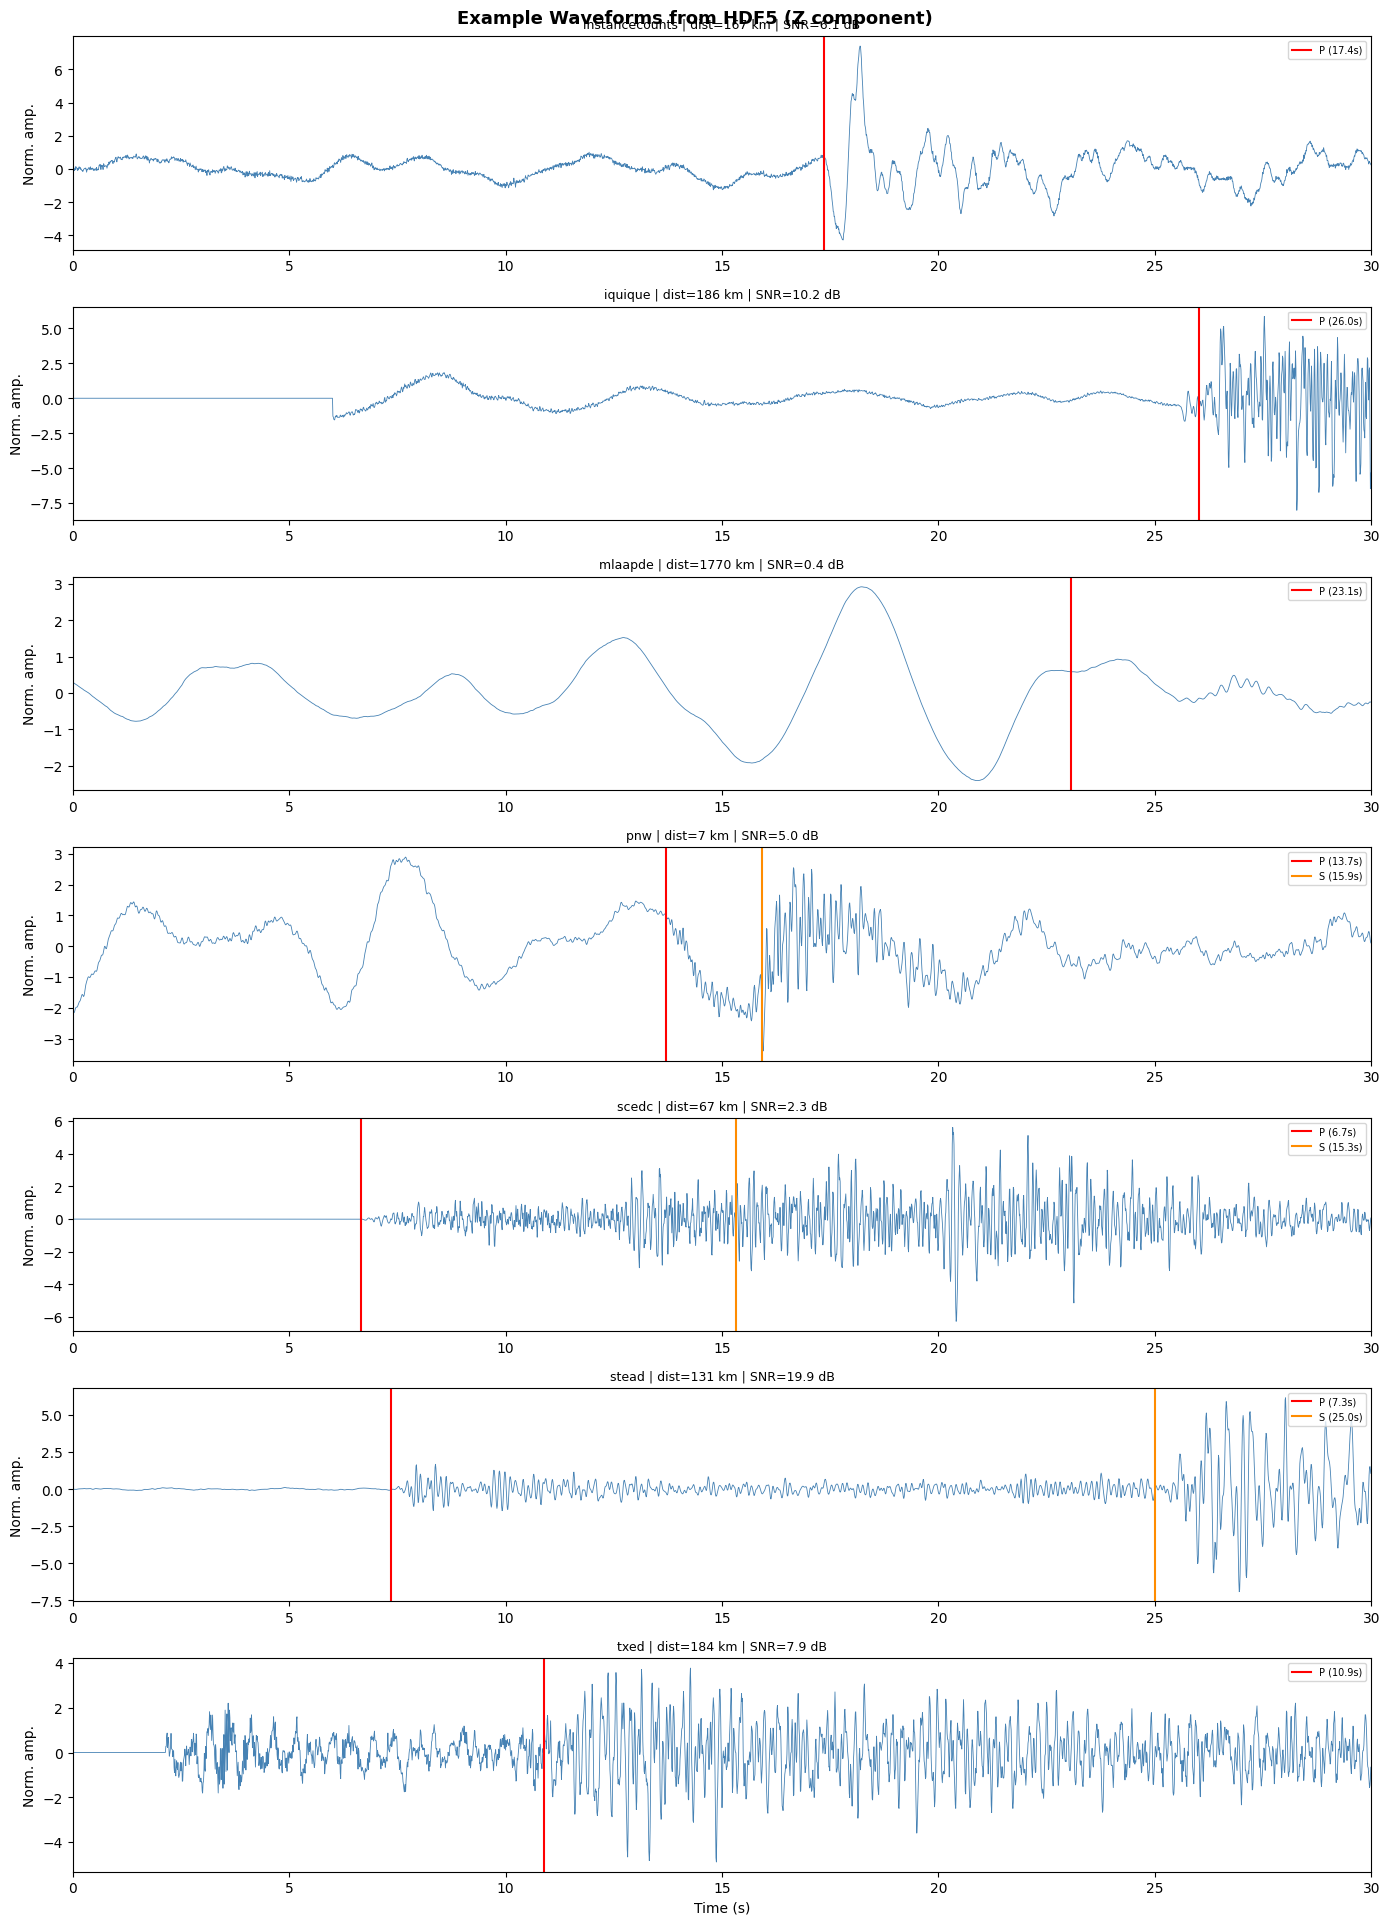

Saved → step2_example_waveforms.png


In [54]:
idx = pd.read_csv("benchmark_waveforms_index.csv")
ok  = idx[idx["status"]=="ok"]
n_ds = ok["dataset"].nunique()
fig, axes = plt.subplots(n_ds, 1, figsize=(14, 2.8*n_ds))
if n_ds == 1: axes = [axes]
fig.suptitle("Example Waveforms from HDF5 (Z component)", fontsize=13, fontweight="bold")

with h5py.File(OUTPUT_HDF5,"r") as hf:
    for ax, (ds_name, grp) in zip(axes, ok.groupby("dataset")):
        row = grp.iloc[(grp["snr_db"]-grp["snr_db"].median()).abs().argsort().iloc[0]]
        tname = row["trace_name"]
        if tname not in hf["waveforms"]:
            ax.set_title(f"{ds_name} — not found in HDF5"); continue
        wave  = hf["waveforms"][tname][:]
        p_pos = int(hf["p_sample"][tname][()])
        s_pos = int(hf["s_sample"][tname][()])
        snr   = float(hf["snr_db"][tname][()])
        t = np.arange(WINDOW_SAMPLES)/TARGET_SR
        ax.plot(t, wave[0], lw=0.6, color="steelblue")
        ax.axvline(p_pos/TARGET_SR, color="red", lw=1.5, label=f"P ({p_pos/TARGET_SR:.1f}s)")
        if s_pos >= 0:
            ax.axvline(s_pos/TARGET_SR, color="darkorange", lw=1.5, label=f"S ({s_pos/TARGET_SR:.1f}s)")
        dist_str = f"{row['distance_km']:.0f} km" if pd.notna(row.get("distance_km")) else "?"
        ax.set_title(f"{ds_name} | dist={dist_str} | SNR={snr:.1f} dB", fontsize=9)
        ax.set_xlim(0, WINDOW_SAMPLES/TARGET_SR); ax.set_ylabel("Norm. amp.")
        ax.legend(fontsize=7, loc="upper right")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("step2_example_waveforms.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved → step2_example_waveforms.png")


## 2.10  Outputs & Usage in Step 3

| File | Description |
|------|-------------|
| `benchmark_waveforms.hdf5` | Preprocessed waveforms, P/S positions, SNR |
| `benchmark_waveforms_index.csv` | Per-trace status, skip reasons, SNR |

### Expected coverage
- stead, instancecounts, pnw, txed, mlaapde → **~3,430 traces** (100% coverage)
- scedc → **up to 326 traces** (from MiniSEED cache)
- iquique, obst2024 → 0 (skipped)
- **Total: ~3,756 traces**

### Loading in Step 3
```python
import h5py, pandas as pd

index = pd.read_csv("benchmark_waveforms_index.csv")
ok    = index[index["status"] == "ok"]

p_traces  = ok[ok["p_in_window"] >= 0]   # P-recall
s_traces  = ok[ok["s_in_window"] >= 0]   # S-recall

with h5py.File("benchmark_waveforms.hdf5", "r") as hf:
    wave  = hf["waveforms"]["my_trace_name"][:]        # (3, 3000) float32
    p_pos = int(hf["p_sample"]["my_trace_name"][()])   # -1 if absent
    s_pos = int(hf["s_sample"]["my_trace_name"][()])   # -1 if absent
```
